In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageColor, ImageDraw, ImageFont

import numpy as np

def display_image(image):
    fig = plt.figure(figsize=(20, 15))
    plt.grid(False)
    plt.imshow(image)


def draw_bounding_box_on_image(image,
                               ymin,
                               xmin,
                               ymax,
                               xmax,
                               color,
                               font,
                               thickness=4,
                               display_str_list=()):
    """Adds a bounding box to an image."""
    draw = ImageDraw.Draw(image)
    im_width, im_height = image.size
    (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                  ymin * im_height, ymax * im_height)
    draw.line([(left, top), (left, bottom), (right, bottom), (right, top),
               (left, top)],
              width=thickness,
              fill=color)

    # If the total height of the display strings added to the top of the bounding
    # box exceeds the top of the image, stack the strings below the bounding box
    # instead of above.
    display_str_heights = [font.getbbox(ds)[3] for ds in display_str_list]
    # Each display_str has a top and bottom margin of 0.05x.
    total_display_str_height = (1 + 2 * 0.05) * sum(display_str_heights)

    if top > total_display_str_height:
        text_bottom = top
    else:
        text_bottom = top + total_display_str_height
    # Reverse list and print from bottom to top.
    for display_str in display_str_list[::-1]:
        bbox = font.getbbox(display_str)
        text_width, text_height = bbox[2], bbox[3]
        margin = np.ceil(0.05 * text_height)
        draw.rectangle([(left, text_bottom - text_height - 2 * margin),
                        (left + text_width, text_bottom)],
                       fill=color)
        draw.text((left + margin, text_bottom - text_height - margin),
                  display_str,
                  fill="black",
                  font=font)
        text_bottom -= text_height - 2 * margin


def draw_boxes(image, boxes, class_names, scores, max_boxes=10, min_score=0.1):
    """Overlay labeled boxes on an image with formatted scores and label names."""
    colors = list(ImageColor.colormap.values())

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf",
                                  25)
    except IOError:
        print("Font not found, using default font.")
        font = ImageFont.load_default()

    for i in range(min(boxes.shape[0], max_boxes)):
        if scores[i] >= min_score:
            ymin, xmin, ymax, xmax = tuple(boxes[i])
            display_str = "{}: {}%".format(class_names[i].decode("ascii"),
                                           int(100 * scores[i]))
            color = colors[hash(class_names[i]) % len(colors)]
            image_pil = Image.fromarray(np.uint8(image)).convert("RGB")
            draw_bounding_box_on_image(
                image_pil,
                ymin,
                xmin,
                ymax,
                xmax,
                color,
                font,
                display_str_list=[display_str])
            np.copyto(image, np.array(image_pil))
    return image

def show_boxes(img, result):
    image_with_boxes = draw_boxes(
        img.numpy(), result["detection_boxes"],
        result["detection_class_entities"], result["detection_scores"])

    display_image(image_with_boxes)

In [2]:
from tracker import load_img, run_detector

import tensorflow_hub as hub


module_handle = "https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1" #@param ["https://tfhub.dev/google/openimages_v4/ssd/mobilenet_v2/1", "https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1"]

detector = hub.load(module_handle).signatures['default']

INFO:tensorflow:Saver not created because there are no variables in the graph to restore


INFO:tensorflow:Saver not created because there are no variables in the graph to restore


Running detector for image: (1836, 3264, 3)


W0000 00:00:1723137967.218929 9878177 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: -2484 } dim { size: -2485 } dim { size: -2486 } dim { size: 1088 } } } inputs { dtype: DT_FLOAT shape { dim { size: -105 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -105 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } value { dtype: DT_INT32 tensor_shape { dim { size: 2 } } int_val: 17 } } device { type: "CPU" model: "0" frequency: 2400 num_cores: 11 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -105 } dim { size: 17 } dim { size: 17 } dim { size: 1088 } } 

Found 100 objects.
Inference time:  15.22445297241211
{'detection_scores': array([0.73280007, 0.7015231 , 0.61412954, 0.58907604, 0.54365855,
       0.51727873, 0.48929223, 0.4373159 , 0.43711618, 0.43506178,
       0.41610575, 0.28832301, 0.24902575, 0.22807805, 0.20662872,
       0.167904  , 0.14356907, 0.10195471, 0.09741083, 0.08236484,
       0.07360057, 0.07238516, 0.06990433, 0.06029322, 0.05909844,
       0.05098187, 0.04445389, 0.04405674, 0.04073641, 0.03734164,
       0.03465836, 0.0330517 , 0.03272476, 0.03152069, 0.03108822,
       0.03028458, 0.02781356, 0.02727771, 0.02526843, 0.02400178,
       0.02196383, 0.02140905, 0.02117087, 0.01752727, 0.01703376,
       0.01635335, 0.01628607, 0.01387243, 0.01277292, 0.0124169 ,
       0.01219832, 0.01183993, 0.01179293, 0.01146815, 0.01109238,
       0.01035665, 0.00973844, 0.00947642, 0.00944345, 0.009385  ,
       0.0089464 , 0.00740749, 0.00692817, 0.00684439, 0.00666755,
       0.00614895, 0.00605091, 0.00549416, 0.0054661 ,

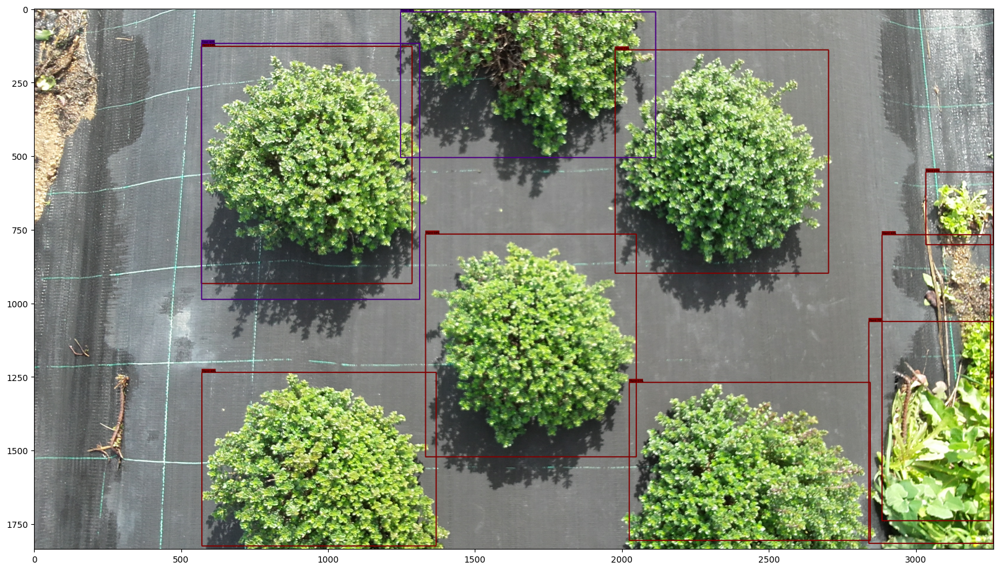

In [3]:
img = load_img("data/ImagesMultiPlant_dataset/p1.jpg")
result = run_detector(detector, img)
print(result)
show_boxes(img, result)

Running detector for image: (340, 603, 3)
Found 100 objects.
Inference time:  3.653223991394043
{'detection_scores': array([0.79153305, 0.74531496, 0.6642116 , 0.63672835, 0.58439916,
       0.55131686, 0.537622  , 0.52324766, 0.4582832 , 0.37538478,
       0.35301745, 0.24553348, 0.18571515, 0.15547921, 0.13625053,
       0.12194228, 0.10208101, 0.07613645, 0.05922715, 0.05417373,
       0.05016488, 0.0488658 , 0.04335003, 0.04151804, 0.0339481 ,
       0.03227478, 0.03049464, 0.02985033, 0.02980497, 0.0296105 ,
       0.02574006, 0.02528094, 0.02461594, 0.0241864 , 0.0233371 ,
       0.02116586, 0.02072459, 0.01891634, 0.0185546 , 0.01807894,
       0.01714145, 0.01342317, 0.0133852 , 0.01303302, 0.01169199,
       0.01083716, 0.01005918, 0.0097993 , 0.00853958, 0.00845052,
       0.00822748, 0.00779864, 0.00737787, 0.00692317, 0.00691617,
       0.00617051, 0.00611241, 0.00604321, 0.00580008, 0.00576571,
       0.00571866, 0.00567391, 0.0054147 , 0.00495191, 0.00487784,
       0.004

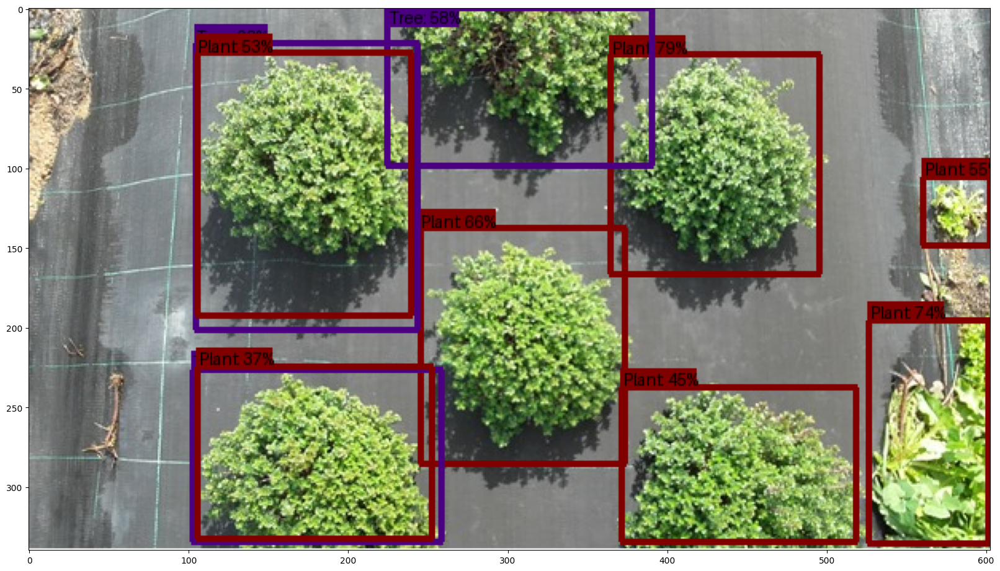

In [4]:
img = load_img("data/ImagesMultiPlant_dataset/p1_low_res.jpg")
result = run_detector(detector, img)
print(result)
show_boxes(img, result)

Running detector for image: (1836, 3264, 3)
Found 100 objects.
Inference time:  3.615157127380371
{'detection_scores': array([0.8037299 , 0.7873942 , 0.6760691 , 0.6261877 , 0.58933747,
       0.58641416, 0.4760163 , 0.3770637 , 0.36570075, 0.2745022 ,
       0.24554794, 0.24391352, 0.156791  , 0.13842073, 0.12356715,
       0.12205379, 0.11124167, 0.07512638, 0.06596074, 0.06092256,
       0.04851158, 0.040922  , 0.0388422 , 0.03766586, 0.03634089,
       0.03081468, 0.02940174, 0.02344775, 0.02209562, 0.02135175,
       0.02071082, 0.02012261, 0.01921104, 0.01886123, 0.01389286,
       0.01356997, 0.01326024, 0.01195655, 0.01155765, 0.00968232,
       0.00917792, 0.00911927, 0.00904652, 0.00773406, 0.00688165,
       0.00663883, 0.0063331 , 0.0059425 , 0.005863  , 0.00576038,
       0.00565932, 0.00511935, 0.0046916 , 0.00415606, 0.00407772,
       0.00395871, 0.00370885, 0.00342841, 0.00339149, 0.0032614 ,
       0.00297822, 0.00286031, 0.00275562, 0.00273966, 0.0027231 ,
       0.0

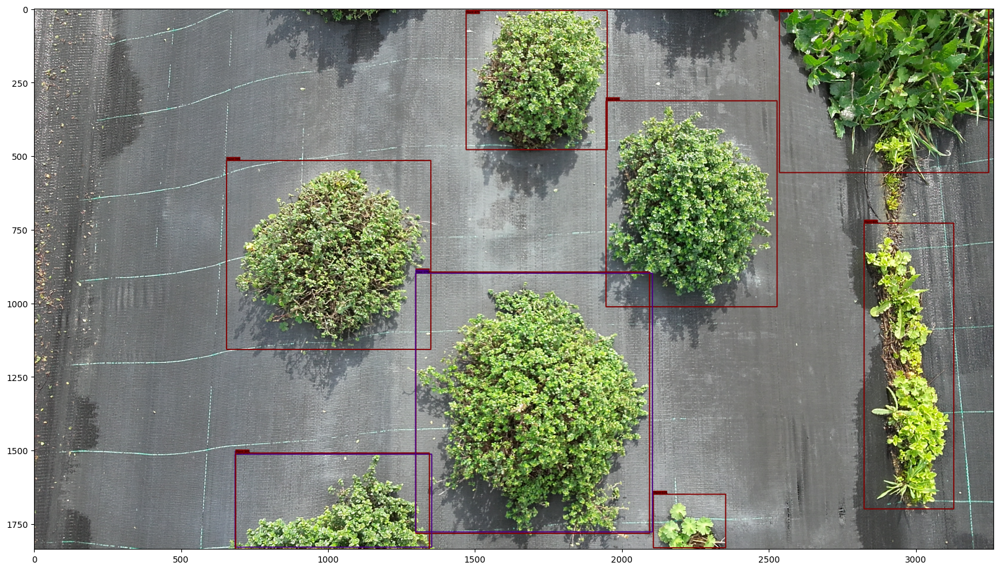

In [5]:
img = load_img("data/ImagesMultiPlant_dataset/p10.jpg")
result = run_detector(detector, img)
print(result)
show_boxes(img, result)

In [6]:
import pandas as pd

from tracker import filter_results

result = filter_results(result)

for key in result.keys():
    if key == "detection_class_names":
        print(key, [x.decode("utf-8") for x in result[key]])
        continue
    if key == "detection_class_entities":
        count = pd.Series(result[key]).value_counts()
        print("Element Count")
        print(count)
    print(key, result[key])

detection_scores [0.8037299  0.7873942  0.6760691  0.6261877  0.58933747 0.58641416]
detection_class_names ['/m/05s2s', '/m/05s2s', '/m/05s2s', '/m/05s2s', '/m/05s2s', '/m/05s2s']
Element Count
b'Plant'    6
Name: count, dtype: int64
detection_class_entities [b'Plant' b'Plant' b'Plant' b'Plant' b'Plant' b'Plant']
detection_boxes [[0.3973576  0.8651482  0.92572767 0.95876884]
 [0.28105265 0.20047578 0.6303186  0.41363493]
 [0.         0.7769267  0.3032705  0.9954043 ]
 [0.89880085 0.64543283 0.9974583  0.7209182 ]
 [0.4880119  0.39790404 0.9706582  0.6417527 ]
 [0.17055503 0.59598815 0.5516794  0.77459085]]
detection_class_labels [334 334 334 334 334 334]
